# Proyecto final: caso TelcoNova
## Contexto empresarial
**TelcoNova** es un operador de telecomunicaciones que brinda servicios móviles de voz y datos a cientos de miles de clientes.

Durante los últimos meses, el área Comercial ha detectado una reducción progresiva del número de clientes activos. El problema no está únicamente en captar nuevos usuarios: algunos clientes actuales están dejando de utilizar los servicios de la compañía y migrando hacia otros operadores.

La empresa dispone de información sobre minutos de llamadas, llamadas dentro y fuera de la red, consumo de datos, recargas, facturación, roaming, uso de redes 2G y 3G, antigüedad y comportamiento mensual. Hasta ahora la utiliza principalmente de forma descriptiva.

La Gerencia Comercial plantea: **¿podemos utilizar el comportamiento histórico de los clientes para anticipar cuáles tienen mayor probabilidad de abandonar la compañía?**

### Problema del negocio
TelcoNova aplica campañas masivas: descuentos del 20 %, bonos de datos, minutos adicionales y paquetes especiales. Enviar promociones a todos los clientes representa un costo elevado. La empresa quiere una estrategia dirigida:

```text
DATOS HISTÓRICOS
        ↓
COMPORTAMIENTO
        ↓
MODELO PREDICTIVO
        ↓
PROBABILIDAD DE CHURN
        ↓
CLIENTES DE ALTO RIESGO 
        ↓
CAMPAÑA DE RETENCIÓN
```

El modelo será una herramienta para **priorizar a qué clientes contactar primero**. La selección de la oferta y la decisión final corresponden al equipo Comercial.

### Rol del alumno y preguntas finales
Asumes el rol de **Analista de Datos del área de Customer Analytics de TelcoNova**. Construirás el primer modelo de churn utilizando Python, Pandas, Matplotlib / Seaborn y Scikit-learn.

1. ¿Es posible identificar anticipadamente a clientes con riesgo de abandono utilizando su comportamiento de consumo, recargas y facturación?
2. Si solamente podemos contactar al grupo con mayor riesgo, ¿cómo utilizamos las predicciones para priorizar la campaña?


## Metodología

| Etapa | Producto del alumno |
| --- | --- |
| Entender y preparar | Diagnóstico de calidad y reglas documentadas |
| Explorar | Perfiles y evolución mensual por abandono |
| Modelar | Referencia simple, k-NN y regresión logística |
| Evaluar | Métricas de clasificación y captura de churn en una campaña |
| Recomendar | Ranking, tamaño de campaña y limitaciones |

Este es un desarrollo guiado, con código completo y preguntas de interpretación. Las conclusiones numéricas se calculan al ejecutar; no se incluyen resultados inventados.


## Dataset y preparación del entorno
Fuente: [Telecom Churn Case Study Hackathon C33 — datos oficiales](https://www.kaggle.com/competitions/telecom-churn-case-study-hackathon-C33/data).

- `train.csv` tiene 172 columnas: `id` identifica al cliente y `churn_probability` es la **etiqueta binaria 0/1**, a pesar de su nombre. 
- `test.csv` tiene 171 columnas, sin etiqueta. `sample.csv` es la plantilla de entrega de la competencia.
- `data_dictionary.csv` explica las abreviaturas. Los sufijos 6, 7 y 8 corresponden a junio, julio y agosto.

Descarga los archivos desde tu cuenta Kaggle, aceptando las reglas, y descomprímelos en:
```text
data/telecom_churn/
    train.csv                 # obligatorio
    test.csv                  # para predecir clientes sin etiqueta
    data_dictionary.csv       # consultar significado y unidades
```

Asegúrate de tener instaladas las librerias necesarias:
```python
%pip install pandas numpy matplotlib seaborn scikit-learn joblib
```
Después reinicia el kernel y ejecuta todas las celdas en orden. La carga se detendrá con instrucciones si falta `train.csv`; no se sustituirá por otro dataset ni por datos sintéticos.


In [51]:
!python -m pip install pandas numpy matplotlib seaborn scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable


## Diccionario de trabajo
| Campo / familia | Interpretación |
| --- | --- |
| `arpu_*` | Ingreso promedio por usuario; aproximación de ingresos, no una factura individual |
| `onnet_mou_*`, `offnet_mou_*` | Minutos dentro y fuera de la red |
| `total_og_mou_*`, `total_ic_mou_*` | Minutos salientes y entrantes |
| `roam_og_mou_*`, `roam_ic_mou_*` | Minutos en roaming |
| `total_rech_amt_*`, `total_rech_num_*` | Monto y número de recargas |
| `vol_2g_mb_*`, `vol_3g_mb_*` | Volumen de datos en MB |
| `aon` | Antigüedad en días |

Consulta las demás columnas en el diccionario oficial. No asignamos moneda peruana a los importes.


## Supuestos del caso y prevención de fuga de información
- TelcoNova es el contexto pedagógico; no afirmamos que sea la empresa de origen de los datos.
- Una fila representa un cliente. Para el caso interpretamos 1 como abandono y 0 como permanencia según la etiqueta provista; no reconstruimos el objetivo a partir del consumo.
- No usaremos identificadores, información posterior a agosto ni la etiqueta como predictores. Una lista explícita de variables impide incorporar accidentalmente otros meses.
- La capacidad inicial es contactar al **10 %** de los clientes. Es una decisión didáctica configurable, no un umbral validado de rentabilidad.
- La partición aleatoria mide generalización entre clientes del mismo conjunto. Antes de uso real se necesita validación en un periodo posterior y confirmar disponibilidad de las variables en la fecha de contacto.


In [ ]:
# 1. Importar librerías y fijar parámetros
from pathlib import Path
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

SEMILLA = 42
FRACCION_CONTACTO = 0.10
UMBRAL = 0.50   # Define el punto de corte para convertir la probabilidad estimada por el modelo en una clase binaria
OBJETIVO = 'churn_probability'
RUTA_DATOS = Path('./data/telecom_churn')  # Cambiar aquí si guardaste los CSV en otra carpeta
RUTA_SALIDA = Path('./exports/telconova')

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 30)
print('Python:', platform.python_version(), '| Scikit-learn:', sklearn.__version__)


Python: 3.11.9 | Scikit-learn: 1.9.0


In [53]:
# 2. Cargar datos originales
ruta_train = RUTA_DATOS / 'train.csv'
if not ruta_train.exists():
    raise FileNotFoundError(
        f'Falta {ruta_train.resolve()}. Descarga train.csv de la competencia C33, '
        'descomprímelo en data/telecom_churn y vuelve a ejecutar el notebook.'
    )

df_original = pd.read_csv(ruta_train)
df_original.columns = df_original.columns.str.strip()

# Verificar columnas duplicadas y la presencia de columnas esperadas
if df_original.columns.duplicated().any():
    raise ValueError('Hay nombres de columnas duplicados tras normalizar espacios.')
if not {'id', OBJETIVO}.issubset(df_original.columns):
    raise ValueError('Se esperaba train.csv de C33 con id y churn_probability.')

print('Filas y columnas:', df_original.shape)
display(df_original.head())

ruta_diccionario = RUTA_DATOS / 'data_dictionary.csv'
if ruta_diccionario.exists():
    display(pd.read_csv(ruta_diccionario))
else:
    print('Diccionario local pendiente: consulta el enlace oficial antes de interpretar campos.')


Filas y columnas: (69999, 172)


,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,...,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,7.527,48.58,124.38,1.29,32.24,...,0,0,0,0,0,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,42.953,0.00,0.00,0.00,0.00,...,0,0,1,0,0,0,0,NaN,1.0,NaN,710,0.0,0.0,0.0,0
2,2,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,60.806,103.176,0.000,0.53,15.93,0.00,53.99,...,0,0,0,0,0,0,0,NaN,NaN,NaN,882,0.0,0.0,0.0,0
3,3,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,156.362,205.260,111.095,7.26,16.01,0.00,68.76,...,0,0,0,0,0,0,0,NaN,NaN,NaN,982,0.0,0.0,0.0,0
4,4,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,240.708,128.191,101.565,21.28,4.83,6.13,56.99,...,6,0,0,0,0,1,0,1.0,1.0,1.0,647,0.0,0.0,0.0,0


,Acronyms,Description
0,CIRCLE_ID,Telecom circle area to which the customer belo...
1,LOC,Local calls within same telecom circle
2,STD,STD calls outside the calling circle
3,IC,Incoming calls
4,OG,Outgoing calls
5,T2T,Operator T to T ie within same operator mobile...
6,T2M,Operator T to other operator mobile
7,T2O,Operator T to other operator fixed line
8,T2F,Operator T to fixed lines of T
9,T2C,Operator T to its own call center


In [54]:
# 3. Inspección de tipos, nulos y duplicados
df_original.info()
calidad = pd.DataFrame({
    'tipo': df_original.dtypes.astype(str),
    'nulos': df_original.isna().sum(),
    'porcentaje_nulos': df_original.isna().mean().mul(100),
    'valores_distintos': df_original.nunique(dropna=True)
}).sort_values('porcentaje_nulos', ascending=False)

display(calidad.head(25))
print('Filas exactamente duplicadas:', df_original.duplicated().sum())
print('IDs repetidos:', df_original['id'].duplicated().sum())
display(df_original.describe().T.head(20))


<class 'pandas.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Columns: 172 entries, id to churn_probability
dtypes: float64(135), int64(28), str(9)
memory usage: 95.9 MB


,tipo,nulos,porcentaje_nulos,valores_distintos
av_rech_amt_data_6,float64,52431,74.902499,792
count_rech_3g_6,float64,52431,74.902499,23
total_rech_data_6,float64,52431,74.902499,36
date_of_last_rech_data_6,str,52431,74.902499,30
fb_user_6,float64,52431,74.902499,2
night_pck_user_6,float64,52431,74.902499,2
count_rech_2g_6,float64,52431,74.902499,30
max_rech_data_6,float64,52431,74.902499,47
arpu_2g_6,float64,52431,74.902499,5389
arpu_3g_6,float64,52431,74.902499,5506


Filas exactamente duplicadas: 0
IDs repetidos: 0


,count,mean,std,min,25%,50%,75%,max
id,69999.0,34999.000000,20207.115084,0.000,17499.500,34999.000,52498.5000,69998.000
circle_id,69999.0,109.000000,0.000000,109.000,109.000,109.000,109.0000,109.000
loc_og_t2o_mou,69297.0,0.000000,0.000000,0.000,0.000,0.000,0.0000,0.000
std_og_t2o_mou,69297.0,0.000000,0.000000,0.000,0.000,0.000,0.0000,0.000
loc_ic_t2o_mou,69297.0,0.000000,0.000000,0.000,0.000,0.000,0.0000,0.000
arpu_6,69999.0,283.134365,334.213918,-2258.709,93.581,197.484,370.7910,27731.088
arpu_7,69999.0,278.185912,344.366927,-1289.715,86.714,191.588,365.3695,35145.834
arpu_8,69999.0,278.858826,351.924315,-945.808,84.095,192.234,369.9090,33543.624
onnet_mou_6,67231.0,133.153275,299.963093,0.000,7.410,34.110,119.3900,7376.710
onnet_mou_7,67312.0,133.894438,311.277193,0.000,6.675,32.280,115.8375,8157.780


## Limpieza: reglas antes de calcular estadísticas
Aquí eliminar toda fila con algún nulo podría descartar demasiados clientes y sesgar la muestra. Conservamos nulos de predictores y los imputaremos dentro del modelo.

Eliminamos solamente filas exactamente duplicadas. Un mismo ID con registros diferentes requiere investigar su origen. Una etiqueta ausente o inválida detiene el análisis: no se puede inventar la respuesta que el modelo debe aprender.

No reemplazamos automáticamente toda ausencia por cero: **desconocido** y **sin consumo** son situaciones distintas. Tampoco eliminamos valores altos por ser atípicos ni todos los ARPU negativos sin confirmar si representan ajustes.


In [55]:
# 4. Limpiar registros y validar la etiqueta
df = df_original.drop_duplicates().copy()
if df['id'].isna().any() or df['id'].duplicated().any():
    raise ValueError('Revisar IDs ausentes o repetidos con información diferente.')
etiqueta = pd.to_numeric(df[OBJETIVO], errors='coerce')

if etiqueta.isna().any() or not etiqueta.isin([0, 1]).all():
    raise ValueError('La etiqueta debe contener exclusivamente 0 y 1, sin nulos.')
df[OBJETIVO] = etiqueta.astype(int)

if df[OBJETIVO].value_counts().min() < 10 or df[OBJETIVO].nunique() != 2:
    raise ValueError('Se necesitan ambas clases y suficientes casos para las particiones.')
df = df.reset_index(drop=True)
print('Filas originales:', len(df_original), '| Filas para el caso:', len(df))


Filas originales: 69999 | Filas para el caso: 69999


## Selección inicial de variables y transformación mensual
Para un primer modelo intermedio trabajamos con familias interpretables, en vez de introducir más de cien atributos de una sola vez. La selección es una decisión previa del caso, no una búsqueda de correlaciones sobre la prueba.

Conservamos los tres meses y añadimos, por cliente, el promedio de junio–julio y el cambio de agosto frente a ese promedio. Un cambio negativo representa una caída, pero no demuestra que sea la causa del abandono. Exigimos ambos meses para el promedio; si faltan, el resultado queda nulo hasta imputar.

Las fechas, códigos de área, otras desagregaciones de llamadas y paquetes quedan fuera del primer modelo para limitar su complejidad. Las variables elegidas son numéricas: no necesitan `LabelEncoder`. Esta función realiza reglas por fila y no aprende estadísticas de otros clientes.


In [56]:
# 5. Definir el contrato de entrada y una transformación reutilizable
FAMILIAS = ['arpu', 'onnet_mou', 'offnet_mou', 'total_og_mou', 'total_ic_mou',
            'roam_og_mou', 'roam_ic_mou', 'total_rech_amt', 'total_rech_num',
            'vol_2g_mb', 'vol_3g_mb']
MESES = [6, 7, 8]
COLUMNAS_BASE = [f'{familia}_{mes}' for familia in FAMILIAS for mes in MESES] + ['aon']

def crear_variables(tabla):
    faltantes = sorted(set(COLUMNAS_BASE) - set(tabla.columns))
    if faltantes:
        raise ValueError(f'Faltan columnas del contrato de entrada: {faltantes}')
    x = tabla[COLUMNAS_BASE].apply(pd.to_numeric, errors='coerce').copy()
    x = x.replace([np.inf, -np.inf], np.nan)
    # Minutos, MB, cantidades, montos de recarga y antigüedad no pueden ser negativos.
    no_negativas = [c for c in COLUMNAS_BASE if not c.startswith('arpu_')]
    x[no_negativas] = x[no_negativas].mask(x[no_negativas] < 0)
    for familia in FAMILIAS:
        promedio = x[[f'{familia}_6', f'{familia}_7']].mean(axis=1, skipna=False)
        x[f'{familia}_prom_6_7'] = promedio
        x[f'{familia}_cambio_8'] = x[f'{familia}_8'] - promedio
    return x

X = crear_variables(df)
y = df[OBJETIVO]

print('Predictores construidos:', X.shape[1])
print('Celdas base no nulas convertidas a nulo por las reglas:',
      (df[COLUMNAS_BASE].notna() & X[COLUMNAS_BASE].isna()).sum().sum())

display(X.head())


Predictores construidos: 56
Celdas base no nulas convertidas a nulo por las reglas: 0


,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,...,total_og_mou_cambio_8,total_ic_mou_prom_6_7,total_ic_mou_cambio_8,roam_og_mou_prom_6_7,roam_og_mou_cambio_8,roam_ic_mou_prom_6_7,roam_ic_mou_cambio_8,total_rech_amt_prom_6_7,total_rech_amt_cambio_8,total_rech_num_prom_6_7,total_rech_num_cambio_8,vol_2g_mb_prom_6_7,vol_2g_mb_cambio_8,vol_3g_mb_prom_6_7,vol_3g_mb_cambio_8
0,31.277,87.009,7.527,48.58,124.38,1.29,32.24,96.68,2.33,81.21,221.68,3.63,11.84,53.04,40.56,...,-147.815,32.440,8.120,0.000,0.000,0.00,0.00,71.0,-61.0,2.5,-0.5,0.000,0.000,0.00,0.00
1,0.000,122.787,42.953,0.00,0.00,0.00,0.00,25.99,30.89,0.00,30.73,31.66,3.44,39.44,25.04,...,16.295,21.440,3.600,0.000,0.000,0.00,0.00,72.5,-22.5,3.5,1.5,176.455,-176.455,1.98,-1.98
2,60.806,103.176,0.000,0.53,15.93,0.00,53.99,82.05,0.00,56.49,99.36,0.00,124.29,33.83,36.64,...,-77.925,79.060,-42.420,0.000,0.000,0.00,0.00,95.0,-95.0,3.0,-1.0,0.000,0.000,0.00,0.00
3,156.362,205.260,111.095,7.26,16.01,0.00,68.76,78.48,50.23,76.03,95.98,53.84,95.11,50.18,83.84,...,-32.165,72.645,11.195,0.000,1.630,0.00,0.00,200.0,-70.0,3.0,0.0,0.000,0.000,0.00,0.00
4,240.708,128.191,101.565,21.28,4.83,6.13,56.99,38.11,9.63,63.26,42.94,15.76,21.54,9.36,28.31,...,-37.340,15.450,12.860,7.865,-7.865,26.82,-26.82,213.0,-91.0,11.5,-3.5,349.845,-136.375,0.00,0.00


## Reservar clientes antes del EDA que utiliza la etiqueta
Dividimos 60 % entrenamiento, 20 % validación y 20 % prueba, con estratificación para conservar aproximadamente la proporción de churn. El EDA y las estadísticas aprendidas utilizan entrenamiento; validación permite elegir modelo; prueba se abre una vez para la evaluación final.

Esta reserva se adelanta a los gráficos para evitar que las decisiones del análisis se adapten a la prueba. No filtramos a clientes de alto valor: el universo del caso es el archivo etiquetado disponible, cuya representatividad debe contrastarse con la cartera real.


In [57]:
# 6. Segmentar con índices para conservar la identidad de cada cliente
idx_desarrollo, idx_prueba = train_test_split(
    df.index, test_size=0.20, random_state=SEMILLA, stratify=y)
idx_entrenamiento, idx_validacion = train_test_split(
    idx_desarrollo, test_size=0.25, random_state=SEMILLA, stratify=y.loc[idx_desarrollo])

X_train, y_train = X.loc[idx_entrenamiento].copy(), y.loc[idx_entrenamiento]
X_val, y_val = X.loc[idx_validacion].copy(), y.loc[idx_validacion]
X_test, y_test = X.loc[idx_prueba].copy(), y.loc[idx_prueba]

display(pd.DataFrame({'partición': ['Entrenamiento', 'Validación', 'Prueba reservada'],
                      'clientes': [len(X_train), len(X_val), len(X_test)]}))
eda = X_train.join(y_train)


,partición,clientes
0,Entrenamiento,41999
1,Validación,14000
2,Prueba reservada,14000


## Análisis exploratorio: de las agrupaciones a los hallazgos
Para comparar segmentos utilizamos la **tasa de abandono dentro de cada grupo**, además de la cantidad de clientes. Contar solamente abandonos favorece a los grupos más grandes.


,clientes,porcentaje
churn,,
0,37720,89.811662
1,4279,10.188338


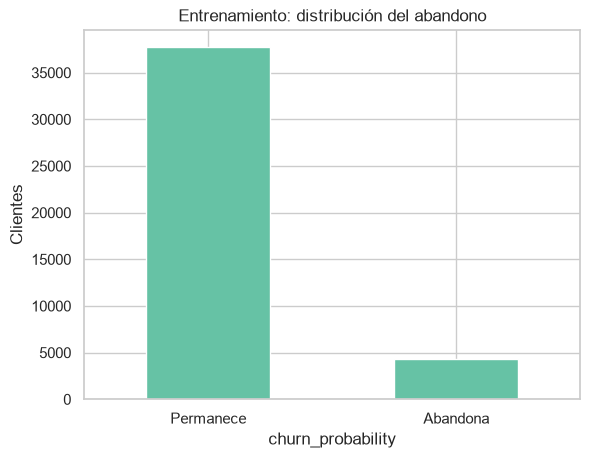

,count,mean,std,min,25%,50%,75%,max,mediana
arpu_8,41999.0,277.077498,363.435713,-945.808,83.239,190.805,367.0915,33543.624,190.805
total_og_mou_8,41999.0,303.063419,479.057574,0.000,38.510,136.780,369.6850,14043.060,136.780
total_rech_amt_8,41999.0,321.133932,444.861698,0.000,90.000,220.000,431.0000,45320.000,220.000
vol_3g_mb_8,41999.0,132.621725,570.237564,0.000,0.000,0.000,0.0000,30036.060,0.000
aon,41999.0,1221.596276,954.929555,180.000,467.000,869.000,1811.0000,4337.000,869.000


Predecir siempre permanencia tendría accuracy de 89.8% en entrenamiento, pero recall de churn igual a cero.


In [58]:
# 7. Distribución del objetivo y estadísticos descriptivos
distribucion = y_train.value_counts().sort_index().rename('clientes').to_frame()
distribucion['porcentaje'] = distribucion['clientes'] / len(y_train) * 100
display(distribucion.rename_axis('churn'))

distribucion['clientes'].rename(index={0: 'Permanece', 1: 'Abandona'}).plot.bar(
    title='Entrenamiento: distribución del abandono', rot=0, ylabel='Clientes')
plt.show()
estadisticos = X_train.describe().T
estadisticos['mediana'] = X_train.median()
display(estadisticos.loc[['arpu_8', 'total_og_mou_8', 'total_rech_amt_8', 'vol_3g_mb_8', 'aon']])
print(f'Predecir siempre permanencia tendría accuracy de {(y_train == 0).mean():.1%} '
      'en entrenamiento, pero recall de churn igual a cero.')


,arpu_8,total_og_mou_8,total_rech_amt_8,vol_2g_mb_8,vol_3g_mb_8,aon
churn_probability,,,,,,
0,208.734,158.225,250.0,0.0,0.0,927.0
1,8.190,0.000,0.0,0.0,0.0,570.0


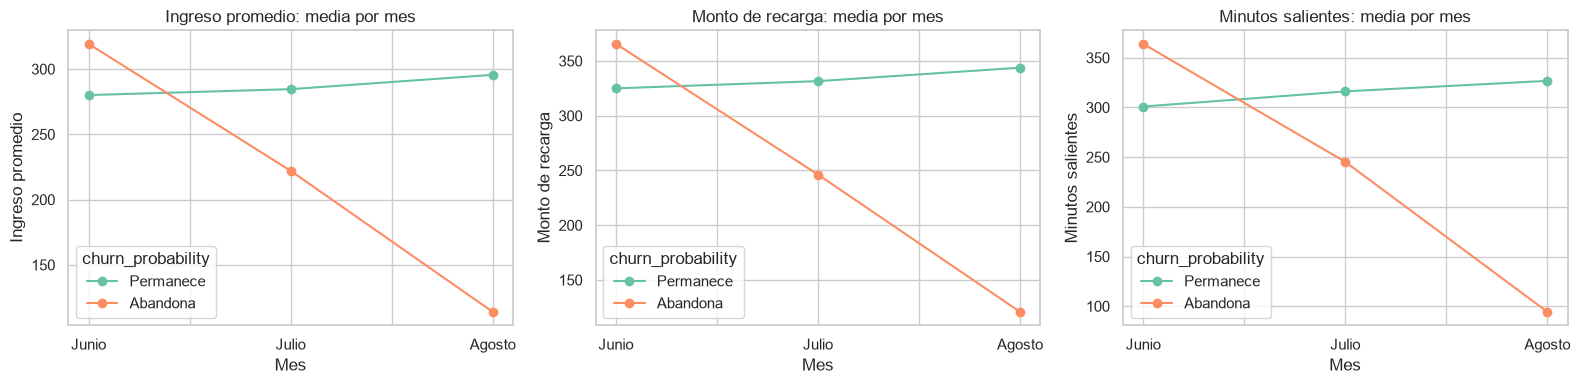

In [59]:
# 8. Agrupar por abandono y observar la evolución mensual
perfil = eda.groupby(OBJETIVO)[['arpu_8', 'total_og_mou_8', 'total_rech_amt_8',
                              'vol_2g_mb_8', 'vol_3g_mb_8', 'aon']].median()
display(perfil)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, familia, unidad in zip(axes, ['arpu', 'total_rech_amt', 'total_og_mou'],
                              ['Ingreso promedio', 'Monto de recarga', 'Minutos salientes']):
    mensual = eda.groupby(OBJETIVO)[[f'{familia}_{m}' for m in MESES]].mean().T
    mensual.index = ['Junio', 'Julio', 'Agosto']
    mensual.rename(columns={0: 'Permanece', 1: 'Abandona'}).plot(marker='o', ax=ax)
    ax.set(title=f'{unidad}: media por mes', ylabel=unidad, xlabel='Mes')
plt.tight_layout()
plt.show()


clientes  abandonos  tasa_churn
segmento_antiguedad tendencia_recarga                                 
Hasta 1 año         Disminuye              3840        943    0.245573
                    Estable o aumenta      3371        210    0.062296
1 a 3 años          Disminuye              9110       1771    0.194402
                    Estable o aumenta      8384        431    0.051407
Más de 3 años       Disminuye              8425        715    0.084866
                    Estable o aumenta      8869        209    0.023565

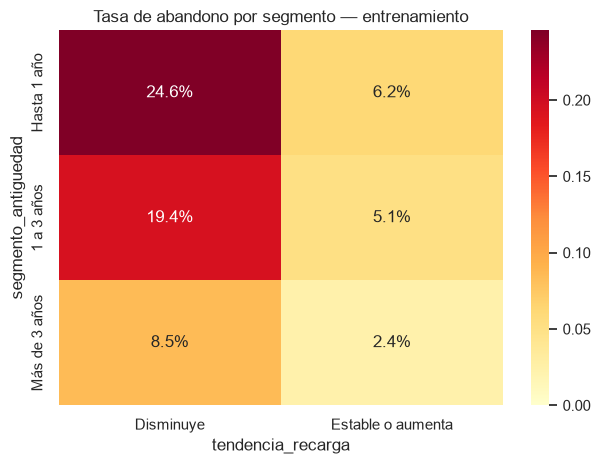

In [60]:
# 9. Antigüedad, caída de recargas y tabla dinámica
eda['segmento_antiguedad'] = pd.cut(eda['aon'], bins=[-np.inf, 365, 1095, np.inf],
                                    labels=['Hasta 1 año', '1 a 3 años', 'Más de 3 años'])
eda['tendencia_recarga'] = np.select(
    [eda['total_rech_amt_cambio_8'].isna(), eda['total_rech_amt_cambio_8'] < 0],
    ['Sin información', 'Disminuye'], default='Estable o aumenta')
segmentos = eda.groupby(['segmento_antiguedad', 'tendencia_recarga'], observed=True).agg(
    clientes=(OBJETIVO, 'size'), abandonos=(OBJETIVO, 'sum'), tasa_churn=(OBJETIVO, 'mean'))
display(segmentos)
tabla_tasas = eda.pivot_table(index='segmento_antiguedad', columns='tendencia_recarga',
                             values=OBJETIVO, aggfunc='mean', observed=True)
sns.heatmap(tabla_tasas, annot=True, fmt='.1%', cmap='YlOrRd', vmin=0)
plt.title('Tasa de abandono por segmento — entrenamiento')
plt.tight_layout()
plt.show()


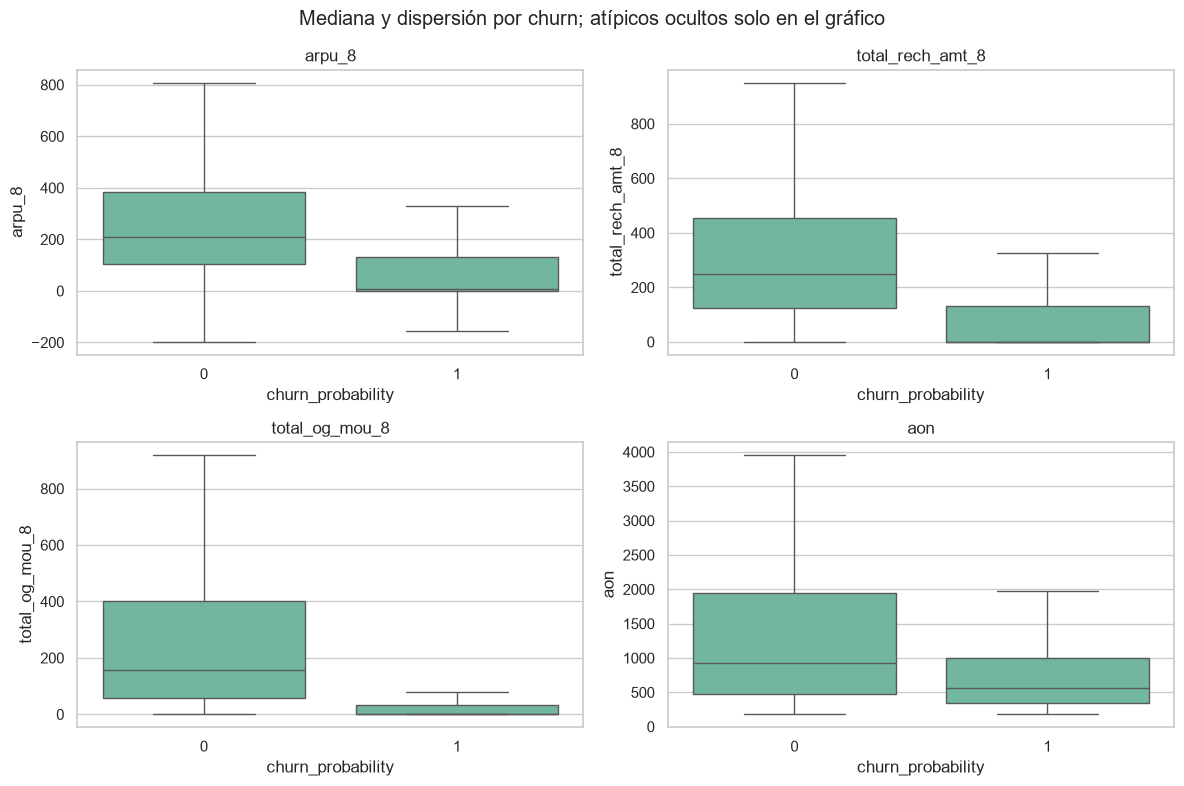

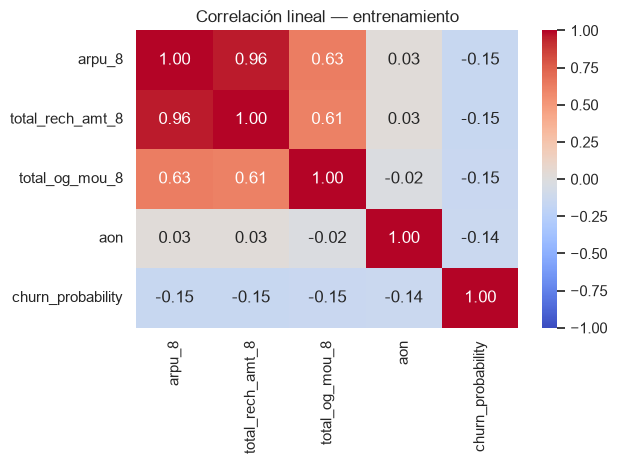

In [61]:
# 10. Distribuciones y correlaciones seleccionadas
variables_eda = ['arpu_8', 'total_rech_amt_8', 'total_og_mou_8', 'aon']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, variable in zip(axes.flat, variables_eda):
    sns.boxplot(data=eda, x=OBJETIVO, y=variable, showfliers=False, ax=ax)
    ax.set_title(variable)
plt.suptitle('Mediana y dispersión por churn; atípicos ocultos solo en el gráfico')
plt.tight_layout()
plt.show()
sns.heatmap(eda[variables_eda + [OBJETIVO]].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlación lineal — entrenamiento')
plt.tight_layout()
plt.show()


### Conclusiones del grafico barplot

#### arpu_8
La caja del grupo 1 parece más baja que la del grupo 0.
Esto sugiere que los clientes que abandonan tienen menor ingreso promedio o menor valor comercial.

#### total_rech_amt_8
También hay una diferencia clara: los clientes con churn tienden a recargar menos dinero.
Eso suele indicar menor engagement o menor intención de uso.

#### total_og_mou_8
Los clientes que abandonan usan menos minutos de llamadas salientes.
Esto se interpreta como menor actividad o menor uso del servicio.

#### aon
La antigüedad también parece diferir: el grupo 1 suele tener menor antigüedad o una distribución distinta.
Esto puede sugerir que los clientes más nuevos tienen más riesgo de churn.

### Conclusión general
El gráfico muestra una señal muy típica de churn:
- menos ingresos
- menos recargas
- menos uso de llamadas
- menor antigüedad o peor permanencia

Eso no significa causalidad, sino asociación: estas variables están relacionadas con la probabilidad de abandono, y por eso el modelo puede usarlas como señales.

**En resumen: los clientes que abandonan parecen ser menos activos y menos valiosos para la empresa en estas métricas.**



In [62]:
# Hallazgos calculados: un ejemplo de cómo comunicar el EDA
tasas_recarga = eda.groupby('tendencia_recarga')[OBJETIVO].agg(['size', 'mean'])
medianas_antiguedad = eda.groupby(OBJETIVO)['aon'].median()

display(Markdown(f'''### Lectura guiada de los resultados
1. En entrenamiento, **{y_train.mean():.1%}** de los clientes tiene etiqueta de abandono.
   Esta frecuencia explica por qué se debe comparar el modelo con una referencia simple.
2. La mediana de antigüedad es **{medianas_antiguedad.loc[0]:.0f} días** entre quienes permanecen
   y **{medianas_antiguedad.loc[1]:.0f} días** entre quienes abandonan.
3. La tabla siguiente contrasta la tasa de churn según la tendencia de recargas. Cada tasa usa
   como denominador los clientes de su propio grupo; no confundirla con su participación en el total.
'''))

display(tasas_recarga.rename(columns={'size': 'clientes', 'mean': 'tasa_churn'}))


### Lectura guiada de los resultados
1. En entrenamiento, **10.2%** de los clientes tiene etiqueta de abandono.
   Esta frecuencia explica por qué se debe comparar el modelo con una referencia simple.
2. La mediana de antigüedad es **927 días** entre quienes permanecen
   y **570 días** entre quienes abandonan.
3. La tabla siguiente contrasta la tasa de churn según la tendencia de recargas. Cada tasa usa
   como denominador los clientes de su propio grupo; no confundirla con su participación en el total.


,clientes,tasa_churn
tendencia_recarga,,
Disminuye,21375,0.160421
Estable o aumenta,20624,0.041214


### Interpretación del alumno
Explica con las tablas y gráficos: ¿están equilibradas las clases?, ¿qué comportamiento mensual diferencia a los grupos?, ¿la caída de recargas cambia entre antigüedades?, ¿qué segmentos tienen pocos clientes?

Redacta tres hallazgos con sus cifras y una limitación. Las asociaciones y las correlaciones sirven para formular hipótesis; no prueban causalidad ni justifican por sí mismas ofrecer un descuento.


<Axes: title={'center': 'Recargas mes 8 por antiguedad'}, xlabel='segmento_antiguedad'>

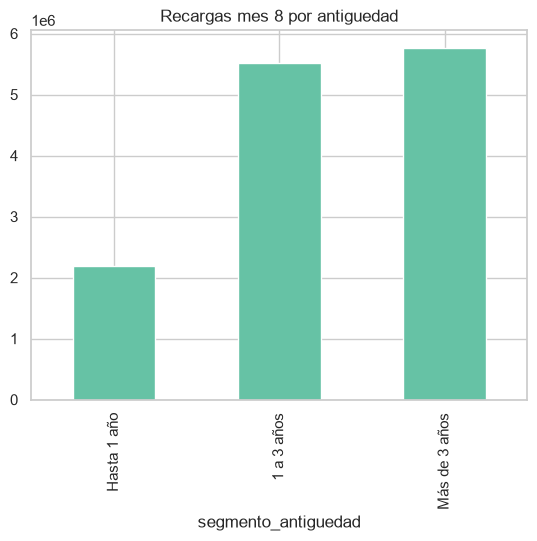

In [ ]:
# Mostrar la cantidad de recargas (mes 8) agrupadas por segmento de antiguedad
eda.groupby('segmento_antiguedad')['total_rech_amt_8'].sum().plot(kind='bar', title='Recargas mes 8 por antiguedad')

<Axes: title={'center': 'Cambio de recargas mes 8 por antiguedad'}, xlabel='segmento_antiguedad'>

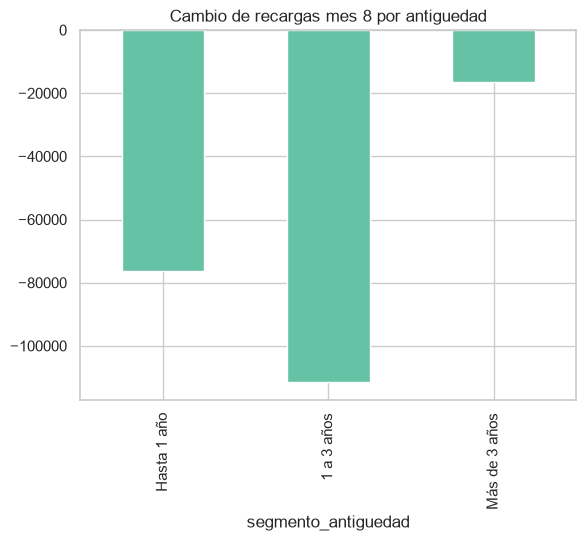

In [73]:
# Mostrar el cambio de recargas (mes 8) agrupadas por segmento de antiguedad
eda.groupby('segmento_antiguedad')['total_rech_amt_cambio_8'].sum().plot(kind='bar', title='Cambio de recargas mes 8 por antiguedad')

## Machine Learning: preparar y entrenar
**X** contiene comportamiento histórico y **y** indica abandono. Eliminamos atributos vacíos o constantes usando solo entrenamiento. Luego el `Pipeline` imputa con la mediana, añade indicadores de ausencia y estandariza.

- **Dummy:** referencia que aprende solamente la frecuencia de las clases. Sus probabilidades iguales no ordenan clientes por riesgo.
- **k-NN (k = 5):** Las escalas importan porque se basa en distancias. En archivos grandes la predicción puede tardar varios minutos.
- **Regresión logística:** segunda alternativa intermedia; produce una puntuación continua y coeficientes interpretables. No se aplica balanceo artificial para no alterar deliberadamente la frecuencia de entrenamiento.

No buscamos numerosos hiperparámetros. Elegimos entre dos modelos por **recall en el grupo contactable**, usando validación y la capacidad fijada previamente. Average Precision (AP) resuelve empates. AP resume la curva precisión–recall; su referencia sin señal es aproximadamente la prevalencia.


In [74]:
# 11. Preparación aprendida exclusivamente en entrenamiento
columnas_modelo = X_train.columns[X_train.nunique(dropna=True) > 1].tolist()
if not columnas_modelo:
    raise ValueError('No hay predictores utilizables en entrenamiento.')

print('Columnas excluidas por ser vacías o constantes:', sorted(set(X.columns) - set(columnas_modelo)))
X_train = X_train[columnas_modelo]
X_val = X_val[columnas_modelo]
X_test = X_test[columnas_modelo]

def construir_pipeline(clasificador):
    return Pipeline([
        ('imputacion', SimpleImputer(strategy='median', add_indicator=True)),
        ('escalado', StandardScaler()),
        ('clasificador', clasificador)
    ])

modelos = {
    'Dummy': construir_pipeline(DummyClassifier(strategy='prior')),
    'k-NN': construir_pipeline(KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    'Regresión logística': construir_pipeline(LogisticRegression(max_iter=2000, random_state=SEMILLA))
}


Columnas excluidas por ser vacías o constantes: []


## Métricas técnicas y comerciales
| Métrica | Pregunta |
| --- | --- |
| Accuracy | ¿Qué fracción de todas las etiquetas acertamos? |
| Precision | De quienes marcamos como churn, ¿cuántos abandonan? |
| Recall | De todos los abandonos, ¿cuántos detectamos? |
| F1 | ¿Qué equilibrio obtenemos entre precision y recall? |
| ROC-AUC / AP | ¿Qué capacidad de discriminación tiene la puntuación? |
| Precision@K | Dentro de los K contactos prioritarios, ¿qué proporción abandona? |
| Recall@K | ¿Qué proporción de todos los abandonos está entre esos K contactos? |
| Lift@K | ¿Cuántas veces supera Precision@K a la tasa general de churn? |

El umbral 0.50 produce una clase para el reporte. La campaña **ordena por puntuación y toma K clientes**, aunque muchos estén por debajo de 0.50. Desempatamos puntuaciones con el ID para que el resultado sea reproducible; esto es especialmente relevante en k-NN.


In [75]:
# 12. Funciones de ranking y evaluación
def crear_ranking(ids, probabilidades, etiquetas=None):
    ranking = pd.DataFrame({'id': np.asarray(ids), 'probabilidad_churn': np.asarray(probabilidades)})
    if etiquetas is not None:
        ranking['churn_real'] = np.asarray(etiquetas)
    ranking = ranking.sort_values(['probabilidad_churn', 'id'], ascending=[False, True]).reset_index(drop=True)
    ranking.insert(0, 'prioridad', np.arange(1, len(ranking) + 1))
    return ranking

def metricas_campana(ranking, fraccion):
    if not 0 < fraccion <= 1:
        raise ValueError('La fracción de contacto debe estar entre 0 y 1.')
    k = max(1, int(np.ceil(len(ranking) * fraccion)))
    capturados = int(ranking.head(k)['churn_real'].sum())
    total_churn = int(ranking['churn_real'].sum())
    tasa_base = ranking['churn_real'].mean()
    precision_k = capturados / k
    return {'contactos': k, 'abandono_capturado': capturados,
            'precision_top': precision_k,
            'recall_top': capturados / total_churn if total_churn else np.nan,
            'lift_top': precision_k / tasa_base if tasa_base else np.nan,
            'churn_esperado_azar': k * tasa_base}

def evaluar(y_real, probabilidades, ids):
    pred = (np.asarray(probabilidades) >= UMBRAL).astype(int)
    resultado = {
        'accuracy': accuracy_score(y_real, pred),
        'precision': precision_score(y_real, pred, zero_division=0),
        'recall': recall_score(y_real, pred, zero_division=0),
        'f1': f1_score(y_real, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_real, probabilidades),
        'average_precision': average_precision_score(y_real, probabilidades)
    }
    resultado.update(metricas_campana(crear_ranking(ids, probabilidades, y_real), FRACCION_CONTACTO))
    return resultado


In [76]:
# 13. Entrenar y comparar únicamente sobre validación
resultados_val = []

for nombre, modelo in modelos.items():
    print('Entrenando y validando:', nombre)
    modelo.fit(X_train, y_train)
    prob_val = modelo.predict_proba(X_val)[:, 1]
    resultados_val.append({'modelo': nombre, **evaluar(y_val, prob_val, df.loc[idx_validacion, 'id'])})
comparacion = pd.DataFrame(resultados_val).set_index('modelo')
display(comparacion.round(4))

Entrenando y validando: Dummy
Entrenando y validando: k-NN
Entrenando y validando: Regresión logística


,accuracy,precision,recall,f1,roc_auc,average_precision,contactos,abandono_capturado,precision_top,recall_top,lift_top,churn_esperado_azar
modelo,,,,,,,,,,,,
Dummy,0.8981,0.0000,0.0000,0.0000,0.5000,0.1019,1400,147,0.1050,0.1030,1.0301,142.7
k-NN,0.9266,0.6996,0.4912,0.5772,0.8397,0.5402,1400,818,0.5843,0.5732,5.7323,142.7
Regresión logística,0.9299,0.7680,0.4478,0.5657,0.8957,0.6397,1400,853,0.6093,0.5978,5.9776,142.7


In [78]:
# Selección del modelo basado en Recall@K y, ante empate, Average Precision (eliminando el Dummy)
candidatos = comparacion.drop(index='Dummy').sort_values(
    ['recall_top', 'average_precision'], ascending=False)
nombre_elegido = candidatos.index[0]
modelo_elegido = modelos[nombre_elegido]
print('Modelo seleccionado por Recall@K y, ante empate, AP:', nombre_elegido)

if candidatos.iloc[0]['lift_top'] <= 1:
    print('La validación no muestra mejora sobre la selección aleatoria. No recomendar despliegue.')

Modelo seleccionado por Recall@K y, ante empate, AP: Regresión logística


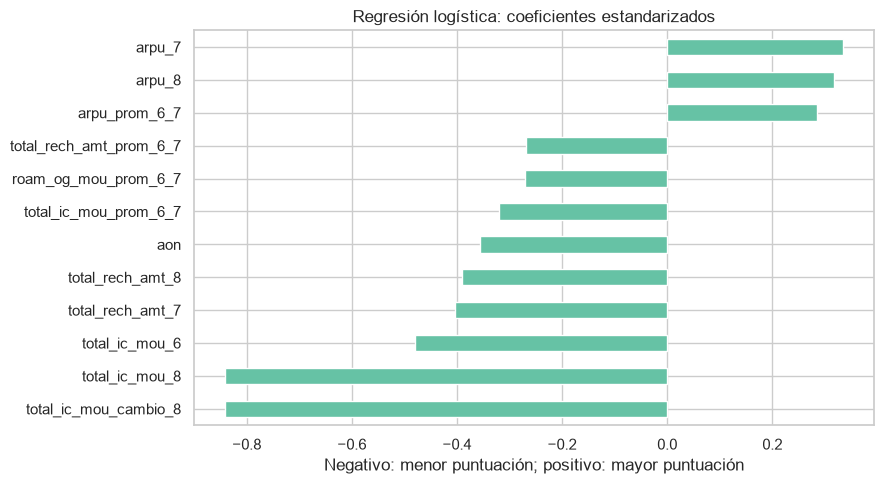

In [79]:
# 14. Interpretar la alternativa logística (coeficientes, no causas)
logistica = modelos['Regresión logística']
nombres_transformados = logistica.named_steps['imputacion'].get_feature_names_out(columnas_modelo)
coeficientes = pd.Series(logistica.named_steps['clasificador'].coef_[0],
                        index=nombres_transformados, name='coeficiente')
mas_relevantes = coeficientes.loc[coeficientes.abs().nlargest(12).index].sort_values()
mas_relevantes.plot.barh(figsize=(9, 5), title='Regresión logística: coeficientes estandarizados')
plt.xlabel('Negativo: menor puntuación; positivo: mayor puntuación')
plt.tight_layout()
plt.show()


Los coeficientes describen la regresión logística aunque el modelo elegido sea k-NN. Variables mensuales y cambios están correlacionados: el signo individual puede ser inestable. La interpretación es condicional al resto de atributos y no representa el efecto de intervenir sobre un cliente.

## Evaluación final en prueba reservada
Se mantiene el modelo entrenado en el 60 % para evaluar una sola vez la decisión tomada con validación. Esta medición precede al entrenamiento final para exportación. No elegimos otro modelo ni otro porcentaje de contacto mirando la prueba.


,Prueba reservada
accuracy,0.9275
precision,0.7658
recall,0.4151
f1,0.5384
roc_auc,0.8923
average_precision,0.6316
contactos,1400.0000
abandono_capturado,841.0000
precision_top,0.6007
recall_top,0.5898


              precision    recall  f1-score   support

   Permanece       0.94      0.99      0.96     12574
    Abandona       0.77      0.42      0.54      1426

    accuracy                           0.93     14000
   macro avg       0.85      0.70      0.75     14000
weighted avg       0.92      0.93      0.92     14000



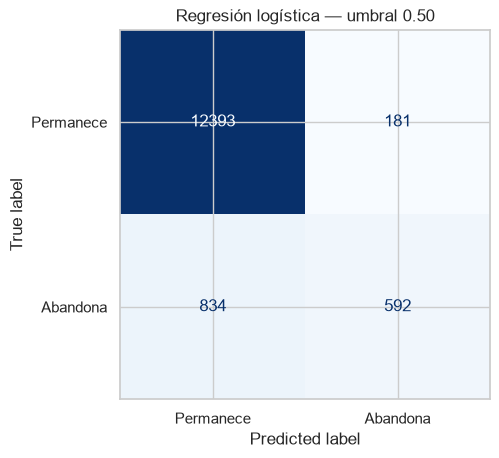

In [80]:
# 15. Reporte y matriz de confusión
prob_test = modelo_elegido.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= UMBRAL).astype(int)
metricas_test = evaluar(y_test, prob_test, df.loc[idx_prueba, 'id'])

display(pd.Series(metricas_test, name='Prueba reservada').to_frame().round(4))
print(classification_report(y_test, pred_test, labels=[0, 1],
                            target_names=['Permanece', 'Abandona'], zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=[0, 1],
    display_labels=['Permanece', 'Abandona'], cmap='Blues', colorbar=False)
plt.title(f'{nombre_elegido} — umbral {UMBRAL:.2f}')
plt.show()


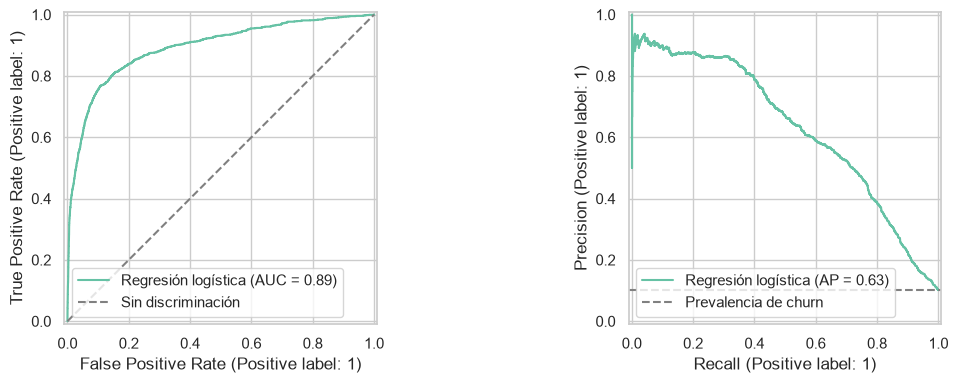

In [81]:
# 16. Curvas ROC y precisión–recall
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, prob_test, name=nombre_elegido, ax=axes[0])
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Sin discriminación')
axes[0].legend()
PrecisionRecallDisplay.from_predictions(y_test, prob_test, name=nombre_elegido, ax=axes[1])
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Prevalencia de churn')
axes[1].legend()
plt.tight_layout()
plt.show()


### Leer los errores desde Comercial
Un falso positivo representa un cliente contactado como potencial abandono que habría permanecido según la etiqueta; un falso negativo es un abandono que el umbral no detectó. Los costos no son iguales. Para la campaña con capacidad fija debemos mirar además los abandonos capturados por el ranking.

`predict_proba` entrega una estimación del modelo, no una garantía individual. No se ha comprobado su calibración; en este caso se usa para ordenar riesgo. Antes de interpretar “0.80” como frecuencia de abandono del 80 %, se necesita evaluar calibración en datos adecuados.


In [82]:
# 17. Simular la campaña en clientes de prueba con etiquetas conocidas
ranking_prueba = crear_ranking(df.loc[idx_prueba, 'id'], prob_test, y_test)
campana_prueba = metricas_campana(ranking_prueba, FRACCION_CONTACTO)
k_prueba = campana_prueba['contactos']
ranking_prueba['contactar'] = ranking_prueba['prioridad'] <= k_prueba

display(ranking_prueba.head(15))
print(f'Contactos disponibles: {k_prueba:,} de {len(ranking_prueba):,}')
print(f"Abandonos dentro del grupo: {campana_prueba['abandono_capturado']:,}")
print(f"Recall@K: {campana_prueba['recall_top']:.1%} | Lift@K: {campana_prueba['lift_top']:.2f}")
print(f"Una campaña aleatoria del mismo tamaño capturaría en promedio "
      f"{campana_prueba['churn_esperado_azar']:.1f} abandonos.")


,prioridad,id,probabilidad_churn,churn_real,contactar
0,1,63987,0.999639,1,True
1,2,34127,0.998288,0,True
2,3,28442,0.990830,1,True
3,4,9948,0.990269,1,True
4,5,491,0.990238,1,True
5,6,54535,0.988504,1,True
6,7,37420,0.987601,1,True
7,8,28509,0.981716,1,True
8,9,9977,0.979152,1,True
9,10,60845,0.977130,1,True


Contactos disponibles: 1,400 de 14,000
Abandonos dentro del grupo: 841
Recall@K: 59.0% | Lift@K: 5.90
Una campaña aleatoria del mismo tamaño capturaría en promedio 142.6 abandonos.


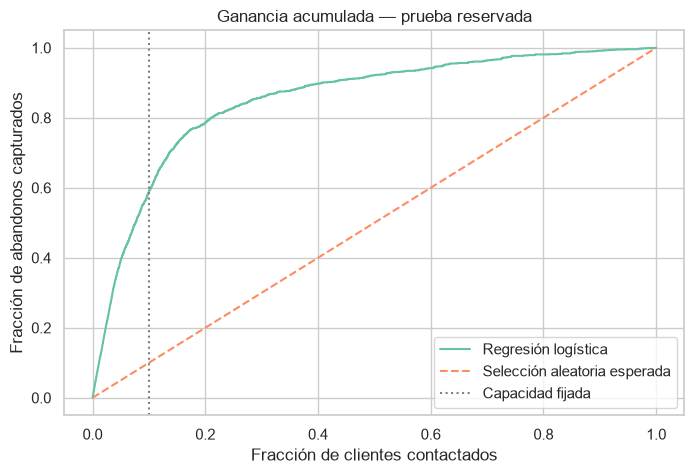

,fraccion_contacto,contactos,abandono_capturado,precision_top,recall_top,lift_top,churn_esperado_azar
0,0.05,700,562,0.8029,0.3941,7.8822,71.3
1,0.10,1400,841,0.6007,0.5898,5.8976,142.6
2,0.20,2800,1121,0.4004,0.7861,3.9306,285.2
3,0.30,4200,1224,0.2914,0.8583,2.8612,427.8


In [83]:
# 18. Curva de ganancia acumulada y escenarios de capacidad
ranking_prueba['fraccion_clientes'] = ranking_prueba['prioridad'] / len(ranking_prueba)
ranking_prueba['recall_acumulado'] = ranking_prueba['churn_real'].cumsum() / y_test.sum()
plt.figure(figsize=(8, 5))
plt.plot(np.r_[0, ranking_prueba['fraccion_clientes']],
         np.r_[0, ranking_prueba['recall_acumulado']], label=nombre_elegido)
plt.plot([0, 1], [0, 1], '--', label='Selección aleatoria esperada')
plt.axvline(k_prueba / len(ranking_prueba), color='gray', linestyle=':', label='Capacidad fijada')
plt.xlabel('Fracción de clientes contactados')
plt.ylabel('Fracción de abandonos capturados')
plt.title('Ganancia acumulada — prueba reservada')
plt.legend()
plt.show()

escenarios = pd.DataFrame([
    {'fraccion_contacto': f, **metricas_campana(ranking_prueba, f)}
    for f in [0.05, 0.10, 0.20, 0.30]
])
display(escenarios.round(4))


Los escenarios ilustran capacidad, pero no se usan para optimizar la política con la prueba. Para cambiar el 10 % se requiere presupuesto y un nuevo proceso de validación.

**Capturar un abandono en el ranking no significa evitarlo.** Reducir contactos reduce volumen de gestión, pero estos datos no miden aceptación de ofertas, efecto incremental, margen ni costo de bonos. Una campaña piloto con asignación aleatoria a contacto y control debe medir retención incremental y rentabilidad.


In [84]:
# 19. Respuesta ejecutiva calculada con los resultados reales de la ejecución
tasa_prueba = y_test.mean()
senal = (metricas_test['roc_auc'] > 0.5 and
         metricas_test['average_precision'] > tasa_prueba and
         campana_prueba['lift_top'] > 1)
diagnostico = ('Hay evidencia descriptiva de capacidad para priorizar en esta partición.' if senal
               else 'No hay evidencia suficiente en estas métricas para recomendar la priorización.')
display(Markdown(f'''### Respuesta a Gerencia
**Modelo:** {nombre_elegido}. {diagnostico}

En prueba, ROC-AUC = **{metricas_test['roc_auc']:.3f}**, AP = **{metricas_test['average_precision']:.3f}**
y tasa base de churn = **{tasa_prueba:.1%}**.

Al contactar a **{k_prueba:,} de {len(ranking_prueba):,} clientes**, el ranking reúne
**{campana_prueba['abandono_capturado']:,} abandonos**, equivalentes al
**{campana_prueba['recall_top']:.1%}** del total. Precision@K =
**{campana_prueba['precision_top']:.1%}** y Lift@K = **{campana_prueba['lift_top']:.2f}**.

La propuesta es ordenar de mayor a menor puntuación y revisar los primeros K clientes con Comercial.
Esta evaluación no incluye intervalos de incertidumbre, no demuestra efecto de la campaña
y solo sustenta anticipación si se confirma el supuesto temporal. Se requiere validación futura y piloto.
'''))


### Respuesta a Gerencia
**Modelo:** Regresión logística. Hay evidencia descriptiva de capacidad para priorizar en esta partición.

En prueba, ROC-AUC = **0.892**, AP = **0.632**
y tasa base de churn = **10.2%**.

Al contactar a **1,400 de 14,000 clientes**, el ranking reúne
**841 abandonos**, equivalentes al
**59.0%** del total. Precision@K =
**60.1%** y Lift@K = **5.90**.

La propuesta es ordenar de mayor a menor puntuación y revisar los primeros K clientes con Comercial.
Esta evaluación no incluye intervalos de incertidumbre, no demuestra efecto de la campaña
y solo sustenta anticipación si se confirma el supuesto temporal. Se requiere validación futura y piloto.


## Predicción individual y preparación del entregable
Primero mostramos una predicción para un cliente de prueba que el modelo no utilizó al entrenar. Luego reajustamos la configuración elegida con todos los clientes etiquetados para generar el artefacto final. Las métricas anteriores corresponden al modelo evaluado, no a una nueva evaluación del artefacto reajustado.


In [85]:
# 20. Predecir un cliente real reservado
cliente = df.loc[[idx_prueba[0]]]
entrada_cliente = crear_variables(cliente)[columnas_modelo]
prob_cliente = modelo_elegido.predict_proba(entrada_cliente)[0, 1]

display(cliente[['id', 'arpu_8', 'total_rech_amt_8', 'total_og_mou_8', 'aon']])
print(f'Puntuación estimada de churn: {prob_cliente:.1%}')
print('Etiqueta observada (solo porque este ejemplo pertenece a prueba):', cliente[OBJETIVO].iloc[0])


,id,arpu_8,total_rech_amt_8,total_og_mou_8,aon
25294,25294,35.192,40,3.16,784


Puntuación estimada de churn: 8.2%
Etiqueta observada (solo porque este ejemplo pertenece a prueba): 0


In [86]:
# 21. Reajustar y guardar modelo, contrato y resultados
modelo_final = clone(modelo_elegido)
modelo_final.fit(X[columnas_modelo], y)
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

artefacto = {
    'pipeline': modelo_final,
    'columnas_modelo': columnas_modelo,
    'columnas_base': COLUMNAS_BASE,
    'familias': FAMILIAS,
    'meses': MESES,
    'version_variables': '1.0: promedio estricto 6-7 y cambio absoluto 8',
    'modelo': nombre_elegido,
    'fraccion_contacto': FRACCION_CONTACTO,
    'umbral_reporte': UMBRAL,
    'sklearn_version': sklearn.__version__,
    'metricas_modelo_evaluado': metricas_test
}

joblib.dump(artefacto, RUTA_SALIDA / 'modelo_telconova.joblib')
comparacion.to_csv(RUTA_SALIDA / 'comparacion_validacion.csv', encoding='utf-8-sig')
ranking_prueba.to_csv(RUTA_SALIDA / 'evaluacion_ranking_prueba.csv', index=False, encoding='utf-8-sig')
escenarios.to_csv(RUTA_SALIDA / 'escenarios_capacidad.csv', index=False, encoding='utf-8-sig')
manifiesto = {
    'fuente': 'https://www.kaggle.com/competitions/telecom-churn-case-study-hackathon-C33/data',
    'sha256_train': hashlib.sha256(ruta_train.read_bytes()).hexdigest(),
    'filas_originales': len(df_original), 'filas_limpias': len(df),
    'semilla': SEMILLA, 'python': platform.python_version(),
    'pandas': pd.__version__, 'numpy': np.__version__, 'sklearn': sklearn.__version__,
    'modelo': nombre_elegido, 'fraccion_contacto': FRACCION_CONTACTO,
    'metricas_prueba': metricas_test
}

(RUTA_SALIDA / 'resumen_ejecucion.json').write_text(
    json.dumps(manifiesto, indent=2, ensure_ascii=False), encoding='utf-8')
cargado = joblib.load(RUTA_SALIDA / 'modelo_telconova.joblib')
np.testing.assert_allclose(modelo_final.predict_proba(entrada_cliente),
                           cargado['pipeline'].predict_proba(entrada_cliente))
print('Modelo recargado y predicciones verificadas. Salidas en:', RUTA_SALIDA.resolve())


Modelo recargado y predicciones verificadas. Salidas en: D:\Clases\NEWHORIZONS\Python\Ejercicios\exports\telconova


La entrada del pipeline son las variables construidas, no el CSV crudo. Para reutilizar el artefacto, ejecuta primero la función `crear_variables` de este notebook y respeta `columnas_modelo`. El archivo guarda imputación, escalado y clasificador; conserva este notebook junto con él para reproducir la transformación. Carga únicamente artefactos `joblib` de confianza.

## Ranking de clientes sin etiqueta
Esta celda es opcional si todavía no descargaste `test.csv`. Produce un ranking operativo de demostración y la lista de contactos. No calcula métricas sobre esos clientes y no envía una entrega a Kaggle. El archivo de competencia no acredita que sean clientes actuales disponibles para contactar; un uso real requiere una cartera vigente y autorización comercial.


In [87]:
# 22. Aplicar el artefacto guardado a los clientes sin etiqueta
ruta_nuevos = RUTA_DATOS / 'test.csv'
if ruta_nuevos.exists():
    nuevos = pd.read_csv(ruta_nuevos)
    nuevos.columns = nuevos.columns.str.strip()
    if nuevos.columns.duplicated().any() or 'id' not in nuevos or OBJETIVO in nuevos:
        raise ValueError('Se esperaba test.csv con id, columnas únicas y sin etiqueta.')
    if nuevos.empty or nuevos['id'].isna().any() or nuevos['id'].duplicated().any():
        raise ValueError('El archivo debe tener clientes con IDs únicos y no nulos.')
    if nuevos['id'].isin(df['id']).any():
        raise ValueError('Hay clientes del entrenamiento en test.csv; revisar la fuente.')
    X_nuevos = crear_variables(nuevos)[cargado['columnas_modelo']]
    probabilidades = cargado['pipeline'].predict_proba(X_nuevos)[:, 1]
    ranking_nuevos = crear_ranking(nuevos['id'], probabilidades)
    k_nuevos = max(1, int(np.ceil(len(nuevos) * cargado['fraccion_contacto'])))
    ranking_nuevos['contactar'] = ranking_nuevos['prioridad'] <= k_nuevos
    ranking_nuevos['accion_sugerida'] = np.where(
        ranking_nuevos['contactar'], 'Revisión por Comercial para contacto', 'Fuera del cupo inicial')
    ranking_nuevos.to_csv(RUTA_SALIDA / 'ranking_clientes_telconova.csv', index=False, encoding='utf-8-sig')
    ranking_nuevos.head(k_nuevos).to_csv(
        RUTA_SALIDA / 'campana_retencion_telconova.csv', index=False, encoding='utf-8-sig')

    display(ranking_nuevos.head(15))
    print(f'Ranking exportado: {len(nuevos):,} clientes; cupo de campaña: {k_nuevos:,}.')
else:
    print('No está test.csv. El desarrollo y la evaluación local terminaron; '
          'añade el archivo y ejecuta esta celda para generar la campaña sin etiquetas.')


,prioridad,id,probabilidad_churn,contactar,accion_sugerida
0,1,74497,1.000000,True,Revisión por Comercial para contacto
1,2,72920,0.999565,True,Revisión por Comercial para contacto
2,3,97570,0.997316,True,Revisión por Comercial para contacto
3,4,80342,0.997241,True,Revisión por Comercial para contacto
4,5,70995,0.995763,True,Revisión por Comercial para contacto
5,6,93282,0.994840,True,Revisión por Comercial para contacto
6,7,83410,0.993687,True,Revisión por Comercial para contacto
7,8,91313,0.990551,True,Revisión por Comercial para contacto
8,9,74778,0.989561,True,Revisión por Comercial para contacto
9,10,73961,0.989328,True,Revisión por Comercial para contacto


Ranking exportado: 30,000 clientes; cupo de campaña: 3,000.


## Recomendación y cierre del caso
Presenta a Gerencia la respuesta calculada y los hallazgos del EDA. Si la evaluación respalda la priorización, propone un piloto dentro del cupo; si no, documenta la insuficiencia y revisa datos y ventanas antes de usar el modelo.

1. **Priorizar:** ordenar por puntuación, seleccionar los primeros K y verificar elegibilidad comercial, vigencia y calidad del contacto.
2. **Decidir:** el analista comparte el ranking; Comercial selecciona la oferta adecuada. Riesgo alto no equivale a mayor respuesta a un descuento.
3. **Medir:** comparar retención y margen incremental entre contacto y control, registrando costo de contacto, incentivo y aceptación.
4. **Mantener:** revisar tasa de churn, nulos, distribución de puntuaciones y desempeño cuando lleguen nuevas etiquetas; reentrenar si la evidencia lo requiere.

### Entregables del alumno
- Notebook ejecutado con fuente, reglas de limpieza y tres hallazgos respaldados por cifras.
- Comparación de modelos y explicación de un falso positivo y un falso negativo.
- Precision@K, Recall@K y Lift@K, con explicación en lenguaje comercial.
- Ranking y lista de contactos cuando se disponga de `test.csv`.
- Recomendación ejecutiva de hasta 200 palabras, con limitaciones temporales y propuesta de piloto.

### Rúbrica sugerida
| Criterio | Puntos |
| --- | ---: |
| Contexto, objetivo y supuestos temporales | 15 |
| Carga, calidad y preparación sin fuga de información | 20 |
| EDA, agrupaciones y visualizaciones interpretadas | 20 |
| Modelos y evaluación reproducible | 25 |
| Priorización y recomendación comercial | 20 |
| **Total** | **100** |

**Extensión opcional:** comparar k = 5, 15 y 25 solamente en validación; estudiar calibración y estabilidad temporal con nuevas cohortes. Conserva una prueba independiente si decides iniciar una nueva búsqueda de modelos.
